In [23]:
!pip install -q ultralytics pillow opencv-python pyyaml matplotlib

In [24]:
import ultralytics
import cv2
import PIL
import yaml
import matplotlib

print("ultralytics OK", ultralytics.__version__)
print("cv2 OK", cv2.__version__)
print("PIL OK")
print("yaml OK")
print("matplotlib OK")

ultralytics OK 8.4.67
cv2 OK 4.13.0
PIL OK
yaml OK
matplotlib OK


In [25]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU: Tesla T4


In [26]:
from google.colab import files
uploaded = files.upload()

Saving yolo26n.pt to yolo26n (2).pt
Saving public_dataset.zip to public_dataset (2).zip


註: 上面這段執行之後可以拉檔案進來

In [27]:
import os
from pathlib import Path

!rm -rf /content/public_dataset
!unzip -q /content/public_dataset.zip -d /content/

DATA_ROOT = Path("/content/public_dataset")

print("Dataset folders:")
!find /content/public_dataset -maxdepth 2 -type f

Dataset folders:
/content/public_dataset/cap/1.jpg
/content/public_dataset/cap/2.jpeg
/content/public_dataset/cap/3.jpeg
/content/public_dataset/cap/0.jpg
/content/public_dataset/cap/4.jpeg
/content/public_dataset/brr/4.png
/content/public_dataset/brr/0.png
/content/public_dataset/brr/3.jpeg
/content/public_dataset/brr/2.jpg
/content/public_dataset/brr/1.jpeg
/content/public_dataset/trala/1.jpg
/content/public_dataset/trala/5.png
/content/public_dataset/trala/0.jpg
/content/public_dataset/trala/4.jpeg
/content/public_dataset/trala/3.png
/content/public_dataset/tung/4.webp
/content/public_dataset/tung/2.jpeg
/content/public_dataset/tung/1.png
/content/public_dataset/tung/3.jpeg
/content/public_dataset/tung/0.jpg


In [28]:
from pathlib import Path

DATA_ROOT = Path("/content/public_dataset")
classes = ["cap", "brr", "trala", "tung"]
valid_ext = {".jpg", ".jpeg", ".png", ".webp"}

for cls in classes:
    files_in_cls = [
        p for p in (DATA_ROOT / cls).iterdir()
        if p.suffix.lower() in valid_ext
    ]
    print(cls, len(files_in_cls), "images")

cap 5 images
brr 5 images
trala 5 images
tung 5 images


In [29]:
import os
import random
import shutil
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter, ImageOps
import numpy as np

SOURCE_DIR = Path("/content/public_dataset")
OUT_DIR = Path("/content/brainrot_yolo")

CLASS_NAMES = ["cap", "brr", "trala", "tung"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

IMG_SIZE = 640
TRAIN_RATIO = 0.85

# 每張原始圖片產生幾張合成圖
AUG_PER_IMAGE = 100

valid_ext = {".jpg", ".jpeg", ".png", ".webp"}

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

for split in ["train", "val"]:
    (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)


def make_background(size=640):
    """
    產生簡單背景，模擬助教把圖片拿到 Tello 前面時，
    背後可能是牆、桌面、白紙、教室背景。
    """
    mode = random.choice(["plain", "noise", "gradient"])

    if mode == "plain":
        base = random.randint(170, 245)
        bg = Image.new(
            "RGB",
            (size, size),
            (
                max(0, min(255, base + random.randint(-20, 20))),
                max(0, min(255, base + random.randint(-20, 20))),
                max(0, min(255, base + random.randint(-20, 20))),
            )
        )

    elif mode == "noise":
        arr = np.random.randint(170, 245, (size, size, 3), dtype=np.uint8)
        bg = Image.fromarray(arr, "RGB")

    else:
        arr = np.zeros((size, size, 3), dtype=np.uint8)
        start = random.randint(170, 230)
        end = random.randint(180, 250)
        for y in range(size):
            val = int(start + (end - start) * y / size)
            arr[y, :, :] = [
                max(0, min(255, val + random.randint(-5, 5))),
                max(0, min(255, val + random.randint(-5, 5))),
                max(0, min(255, val + random.randint(-5, 5))),
            ]
        bg = Image.fromarray(arr, "RGB")

    return bg


def augment_object(img):
    """
    對物件圖片做增強：亮度、對比、顏色、旋轉、模糊。
    """
    img = img.convert("RGB")

    # 有些圖可能有透明邊或白邊，先保守處理
    img = ImageOps.contain(img, (IMG_SIZE, IMG_SIZE))

    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.75, 1.25))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.75, 1.30))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.80, 1.25))

    angle = random.uniform(-15, 15)
    img = img.rotate(angle, expand=True, fillcolor=(255, 255, 255))

    if random.random() < 0.25:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 0.8)))

    return img


def paste_object_on_bg(obj_img, bg):
    """
    把物件貼到背景上，回傳合成圖與 bbox。
    """
    # 物件寬度佔畫面的 35% ~ 85%
    target_w = random.randint(int(IMG_SIZE * 0.35), int(IMG_SIZE * 0.85))
    scale = target_w / obj_img.width
    target_h = int(obj_img.height * scale)

    if target_h > int(IMG_SIZE * 0.9):
        target_h = int(IMG_SIZE * 0.9)
        scale = target_h / obj_img.height
        target_w = int(obj_img.width * scale)

    target_w = max(10, min(IMG_SIZE - 1, target_w))
    target_h = max(10, min(IMG_SIZE - 1, target_h))

    obj_img = obj_img.resize((target_w, target_h))

    max_x = IMG_SIZE - target_w
    max_y = IMG_SIZE - target_h

    x1 = random.randint(0, max_x)
    y1 = random.randint(0, max_y)
    x2 = x1 + target_w
    y2 = y1 + target_h

    bg.paste(obj_img, (x1, y1))

    return bg, (x1, y1, x2, y2)


def yolo_label_from_bbox(class_id, bbox):
    """
    YOLO label 格式：
    class_id x_center y_center width height
    全部 normalized 到 0~1。
    """
    x1, y1, x2, y2 = bbox

    x_center = ((x1 + x2) / 2) / IMG_SIZE
    y_center = ((y1 + y2) / 2) / IMG_SIZE
    w = (x2 - x1) / IMG_SIZE
    h = (y2 - y1) / IMG_SIZE

    return f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"


count = 0

for class_name in CLASS_NAMES:
    class_dir = SOURCE_DIR / class_name

    if not class_dir.exists():
        raise FileNotFoundError(f"找不到資料夾：{class_dir}")

    image_paths = [
        p for p in class_dir.iterdir()
        if p.suffix.lower() in valid_ext
    ]

    for img_path in image_paths:
        for aug_idx in range(AUG_PER_IMAGE):
            split = "train" if random.random() < TRAIN_RATIO else "val"

            obj = Image.open(img_path).convert("RGB")
            obj = augment_object(obj)

            bg = make_background(IMG_SIZE)
            composed, bbox = paste_object_on_bg(obj, bg)

            filename = f"{class_name}_{img_path.stem}_{aug_idx:03d}.jpg"

            image_out = OUT_DIR / "images" / split / filename
            label_out = OUT_DIR / "labels" / split / filename.replace(".jpg", ".txt")

            composed.save(image_out, quality=95)

            label_line = yolo_label_from_bbox(CLASS_TO_ID[class_name], bbox)
            label_out.write_text(label_line + "\n")

            count += 1

print("Generated images:", count)
print("Output dataset:", OUT_DIR)

/tmp/ipykernel_1003/1811155849.py:64: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bg = Image.fromarray(arr, "RGB")
/tmp/ipykernel_1003/1811155849.py:51: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bg = Image.fromarray(arr, "RGB")


Generated images: 2000
Output dataset: /content/brainrot_yolo


In [30]:
yaml_text = """
path: /content/brainrot_yolo
train: images/train
val: images/val

names:
  0: cap
  1: brr
  2: trala
  3: tung
"""

yaml_path = "/content/brainrot_yolo/brainrot.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print(open(yaml_path).read())


path: /content/brainrot_yolo
train: images/train
val: images/val

names:
  0: cap
  1: brr
  2: trala
  3: tung



In [31]:
!find /content/brainrot_yolo -maxdepth 3 -type d
print("train images:", len(list(Path("/content/brainrot_yolo/images/train").glob("*.jpg"))))
print("val images:", len(list(Path("/content/brainrot_yolo/images/val").glob("*.jpg"))))
print("train labels:", len(list(Path("/content/brainrot_yolo/labels/train").glob("*.txt"))))
print("val labels:", len(list(Path("/content/brainrot_yolo/labels/val").glob("*.txt"))))

/content/brainrot_yolo
/content/brainrot_yolo/labels
/content/brainrot_yolo/labels/train
/content/brainrot_yolo/labels/val
/content/brainrot_yolo/images
/content/brainrot_yolo/images/train
/content/brainrot_yolo/images/val
train images: 1710
val images: 290
train labels: 1710
val labels: 290


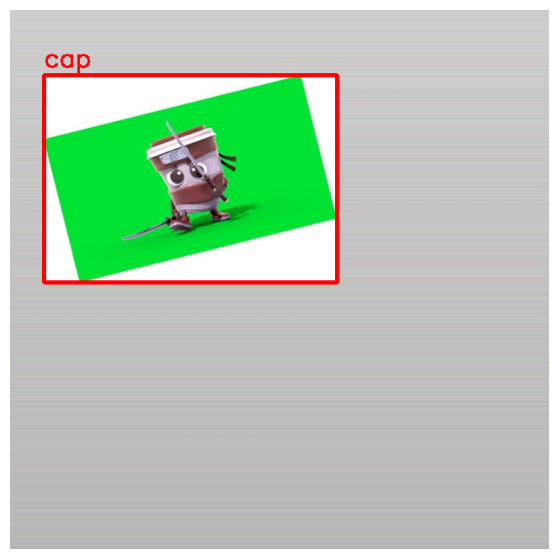

Image: /content/brainrot_yolo/images/train/cap_3_050.jpg
Label:
0 0.334375 0.313281 0.543750 0.385937



In [32]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

img_files = list(Path("/content/brainrot_yolo/images/train").glob("*.jpg"))

sample_img = random.choice(img_files)
sample_label = Path(str(sample_img).replace("/images/", "/labels/").replace(".jpg", ".txt"))

img = cv2.imread(str(sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

for line in sample_label.read_text().strip().splitlines():
    cls_id, xc, yc, bw, bh = line.split()
    cls_id = int(cls_id)
    xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

    x1 = int((xc - bw / 2) * w)
    y1 = int((yc - bh / 2) * h)
    x2 = int((xc + bw / 2) * w)
    y2 = int((yc + bh / 2) * h)

    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
    cv2.putText(
        img,
        CLASS_NAMES[cls_id],
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

print("Image:", sample_img)
print("Label:")
print(sample_label.read_text())

In [33]:
from ultralytics import YOLO

model = YOLO("/content/yolo26n.pt")

results = model.train(
    data="/content/brainrot_yolo/brainrot.yaml",
    epochs=80,
    imgsz=640,
    batch=16,
    patience=20,
    workers=2,
    project="/content/runs/detect",
    name="brainrot",
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brainrot_yolo/brainrot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brainrot-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

In [34]:
model = YOLO("/content/runs/detect/brainrot/weights/best.pt")

metrics = model.val(
    data="/content/brainrot_yolo/brainrot.yaml",
    imgsz=640,
    conf=0.25
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2422.2±1299.7 MB/s, size: 160.3 KB)
val: Scanning /content/brainrot_yolo/labels/val.cache... 290 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 290/290 121.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.2it/s 4.6s
                   all        290        290      0.972      0.824      0.824       0.81
                   cap         79         79          1      0.722      0.725      0.714
                   brr         80         80          1      0.787      0.785      0.776
                 trala         59         59          1      0.814      0.815      0.809
                  tung         72         72      0.886      0.972      0.971      0.939
Speed: 2.4ms preprocess, 5.1ms inferenc

In [35]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/brainrot/weights/best.pt")

results = model.predict(
    source="/content/brainrot_yolo/images/val",
    conf=0.25,
    save=True,
    project="/content/runs/detect",
    name="brainrot_predict",
    exist_ok=True
)

print("Prediction saved to /content/runs/detect/brainrot_predict")


image 1/290 /content/brainrot_yolo/images/val/brr_0_016.jpg: 640x640 1 brr, 12.5ms
image 2/290 /content/brainrot_yolo/images/val/brr_0_022.jpg: 640x640 1 brr, 7.9ms
image 3/290 /content/brainrot_yolo/images/val/brr_0_026.jpg: 640x640 (no detections), 9.3ms
image 4/290 /content/brainrot_yolo/images/val/brr_0_028.jpg: 640x640 1 brr, 8.0ms
image 5/290 /content/brainrot_yolo/images/val/brr_0_032.jpg: 640x640 1 brr, 8.9ms
image 6/290 /content/brainrot_yolo/images/val/brr_0_038.jpg: 640x640 1 brr, 8.6ms
image 7/290 /content/brainrot_yolo/images/val/brr_0_043.jpg: 640x640 1 brr, 8.2ms
image 8/290 /content/brainrot_yolo/images/val/brr_0_046.jpg: 640x640 1 brr, 8.1ms
image 9/290 /content/brainrot_yolo/images/val/brr_0_047.jpg: 640x640 1 brr, 8.8ms
image 10/290 /content/brainrot_yolo/images/val/brr_0_052.jpg: 640x640 1 brr, 8.0ms
image 11/290 /content/brainrot_yolo/images/val/brr_0_053.jpg: 640x640 1 brr, 8.1ms
image 12/290 /content/brainrot_yolo/images/val/brr_0_056.jpg: 640x640 1 brr, 8.4ms
i

num prediction images: 525


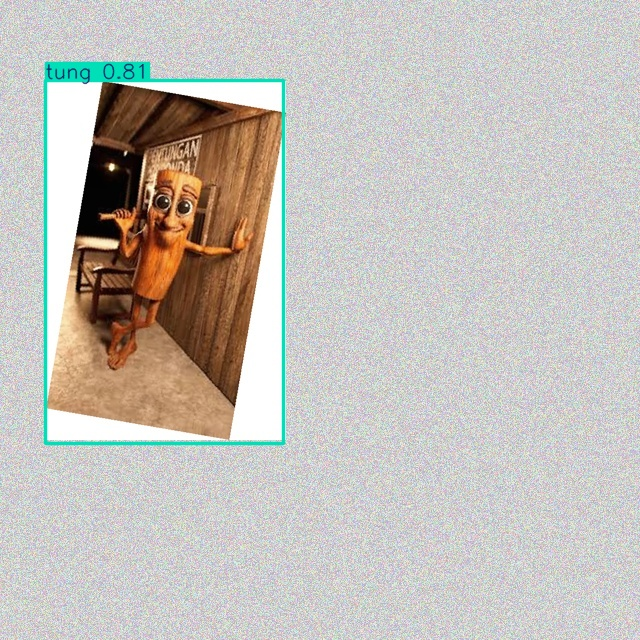

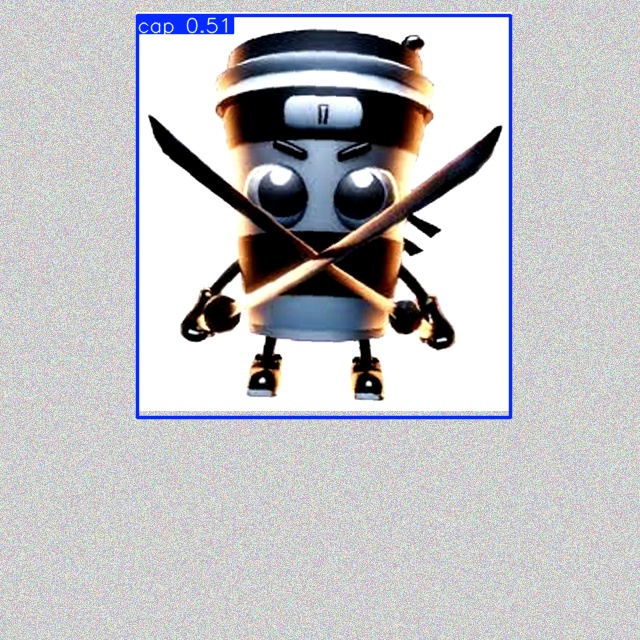

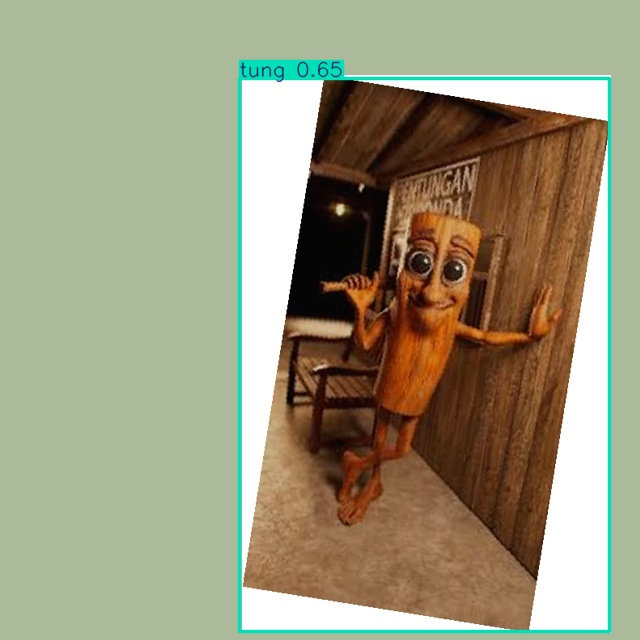

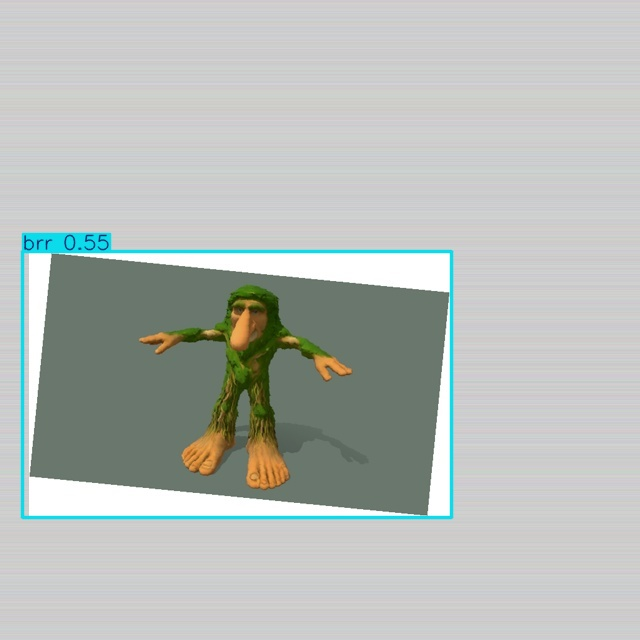

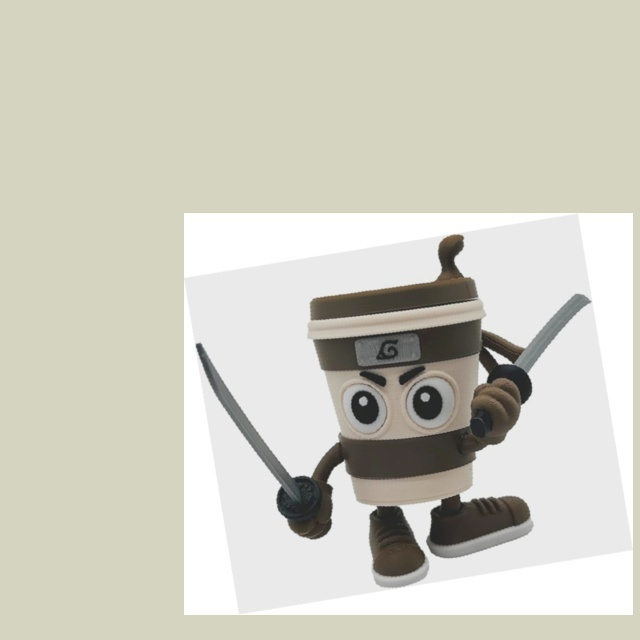

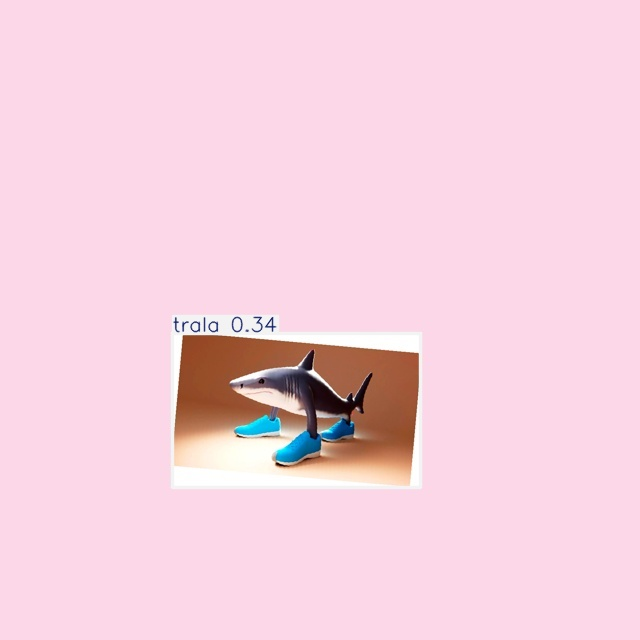

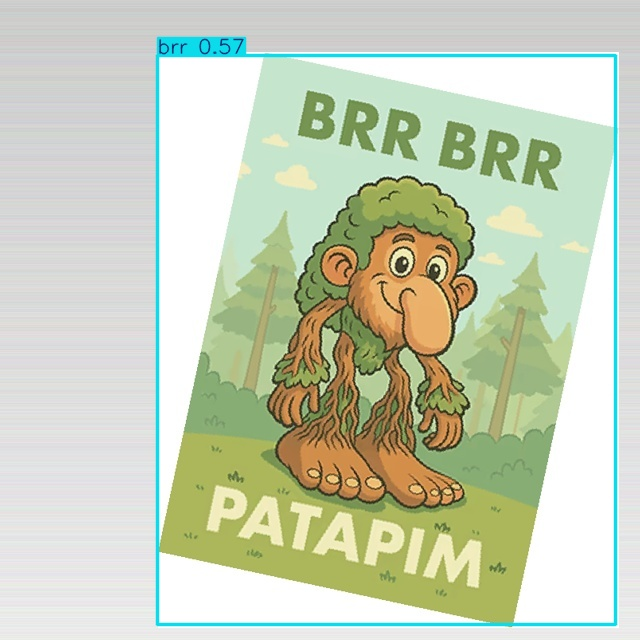

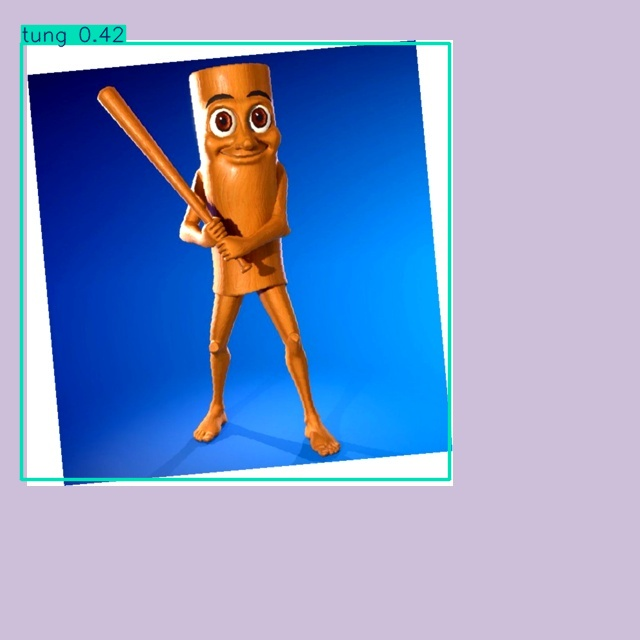

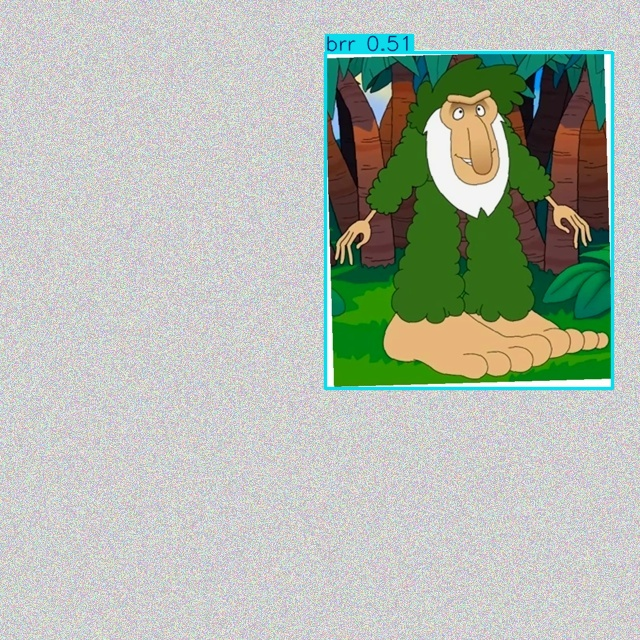

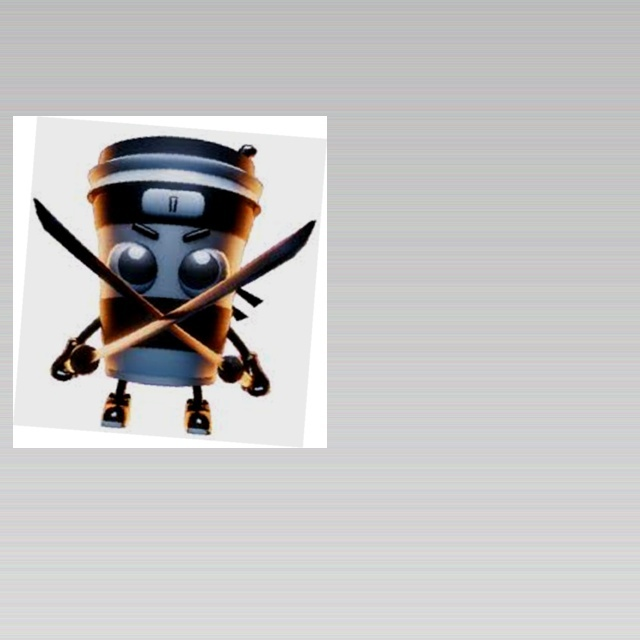

In [36]:
import glob
from IPython.display import Image, display

pred_imgs = glob.glob("/content/runs/detect/brainrot_predict/*.jpg")

print("num prediction images:", len(pred_imgs))

for p in pred_imgs[:10]:
    display(Image(filename=p))

In [37]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/brainrot/weights/best.pt")
model.export(format="onnx", imgsz=640)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/brainrot/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (20.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 266ms
Prepared 4 packages in 1.86s
Installed 4 packages in 370ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimmin

'/content/runs/detect/brainrot/weights/best.onnx'

In [38]:
!ls -lh /content/runs/detect/brainrot/weights

total 51M
-rw-r--r-- 1 root root 11M Jun 14 11:32 best.onnx
-rw-r--r-- 1 root root 21M Jun 14 10:04 best.pt
-rw-r--r-- 1 root root 21M Jun 14 10:05 last.pt


In [39]:
!cp /content/runs/detect/brainrot/weights/best.pt /content/brainrot_detect.pt
!cp /content/runs/detect/brainrot/weights/best.onnx /content/brainrot_detect.onnx

!ls -lh /content/brainrot_detect.pt /content/brainrot_detect.onnx

-rw-r--r-- 1 root root 11M Jun 14 11:32 /content/brainrot_detect.onnx
-rw-r--r-- 1 root root 21M Jun 14 11:32 /content/brainrot_detect.pt


In [40]:
from google.colab import files

files.download("/content/brainrot_detect.pt")
files.download("/content/brainrot_detect.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

test image: /content/brainrot_yolo/images/val/cap_1_071.jpg

image 1/1 /content/brainrot_yolo/images/val/cap_1_071.jpg: 640x640 1 cap, 10.0ms
Speed: 2.3ms preprocess, 10.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/single_test
cap 0.41876062750816345 [242.3195037841797, 146.57135009765625, 576.8673706054688, 443.10321044921875]


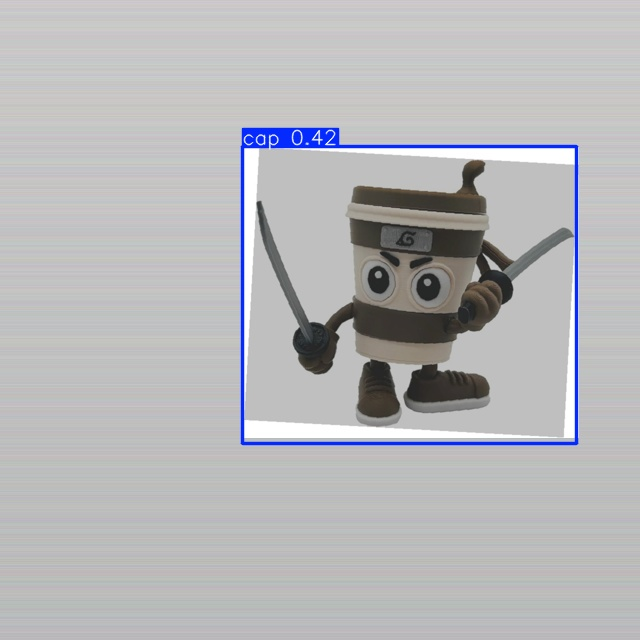

In [42]:
from ultralytics import YOLO
import random
from pathlib import Path
from IPython.display import Image, display

model = YOLO("/content/brainrot_detect.pt")

test_img = random.choice(list(Path("/content/brainrot_yolo/images/val").glob("*.jpg")))
print("test image:", test_img)

results = model.predict(
    source=str(test_img),
    conf=0.15,
    save=True,
    project="/content/runs/detect",
    name="single_test",
    exist_ok=True
)

for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = model.names[cls_id]
        xyxy = box.xyxy[0].tolist()
        print(label, conf, xyxy)

display(Image(filename=f"/content/runs/detect/single_test/{test_img.name}"))